In [1]:
# Imports required for the MC-DFM simulation
import sys
sys.path.append('../')
from Scattering_Simulator import pairwise_method
from Scattering_Simulator import fitting
from Scattering_Simulator import Read_PDB
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------------
# Helper function to generate random points uniformly inside a cylinder
# ------------------------------------------------------------------
def generate_uniform_points_in_cylinder(radius, length, N, seed=None):
    """
    Generate N random points uniformly inside a right circular cylinder
    aligned along the z‑axis, centered at the origin.
    """
    rng = np.random.default_rng(seed)
    # radial part
    u = rng.random(N)
    r = radius * np.sqrt(u)            # r^2 proportional to u
    theta = rng.uniform(0, 2*np.pi, N)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    # axial part
    z = rng.uniform(-0.5*length, 0.5*length, N)
    return np.column_stack((x, y, z))

# ------------------------------------------------------------------
# Polydispersity setup
# ------------------------------------------------------------------
# Cylinder length (constant for all cylinders)
cylinder_length = 200.0        # Å

# Radius distribution parameters
radius_mean = 20.0              # Å
radius_std  = 10.0              # Å

# Sample radii from the normal distribution, keep positive values
np.random.seed(42)
sample_size = 10000
sample_radii = np.random.normal(loc=radius_mean, scale=radius_std, size=sample_size)
sample_radii = sample_radii[sample_radii > 0]

# Discretise into size classes (bins)
num_bins = 40
hist, bin_edges = np.histogram(sample_radii, bins=num_bins, density=False)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])   # representative radius for each bin

# Proportional probabilities of each size class
proportions = hist / hist.sum()

# ------------------------------------------------------------------
# Build coordinate arrays for each size class
# ------------------------------------------------------------------
objects = []
base_points_per_cylinder = 20000   # before volume scaling

# Compute volumes for each size class (cylinder volume = πr^2L)
volumes = np.pi * bin_centers**2 * cylinder_length
avg_volume = volumes.mean()

for i, rad in enumerate(bin_centers):
    # Number of points scaled by volume relative to the average
    N_points = int(base_points_per_cylinder * (volumes[i] / avg_volume))
    if N_points < 1:
        N_points = 1

    # Generate random points inside the cylinder
    coords = generate_uniform_points_in_cylinder(rad, cylinder_length, N_points, seed=42+i)

    # Add SLD difference as the 4th column (here we assume a uniform SLD of 1.0)
    coords = np.hstack((coords, np.full((N_points, 1), 1.0)))
    objects.append(coords)

# ------------------------------------------------------------------
# Generate center-of-mass coordinates for all cylinders in the box
# ------------------------------------------------------------------
# Estimate a separation that prevents overlap: 2*max_radius + length
size_of_object = 2 * (np.max(bin_centers) + cylinder_length)
center_of_mass_coordinates = pairwise_method.generate_coordinates_for_polydisperse_system(
    size_of_object=size_of_object)

# ------------------------------------------------------------------
# Place the cylinders on the generated coordinates with the specified proportions
# ------------------------------------------------------------------
all_coordinates = pairwise_method.place_objects_on_coordinates(
    center_of_mass_coordinates,
    objects,
    proportions)

# ------------------------------------------------------------------
# Simulate the scattering curve for the polydisperse cylinder system
# ------------------------------------------------------------------
n_pairwise = 10000000
histogram_bins = 10000
q = np.geomspace(0.01, 1.0, 3000)

Iq = fitting.simulate_scattering(
    all_coordinates,
    q,
    histogram_bins,
    n_pairwise,
    mode='single')

# ------------------------------------------------------------------
# Plot the results
# ------------------------------------------------------------------
#

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

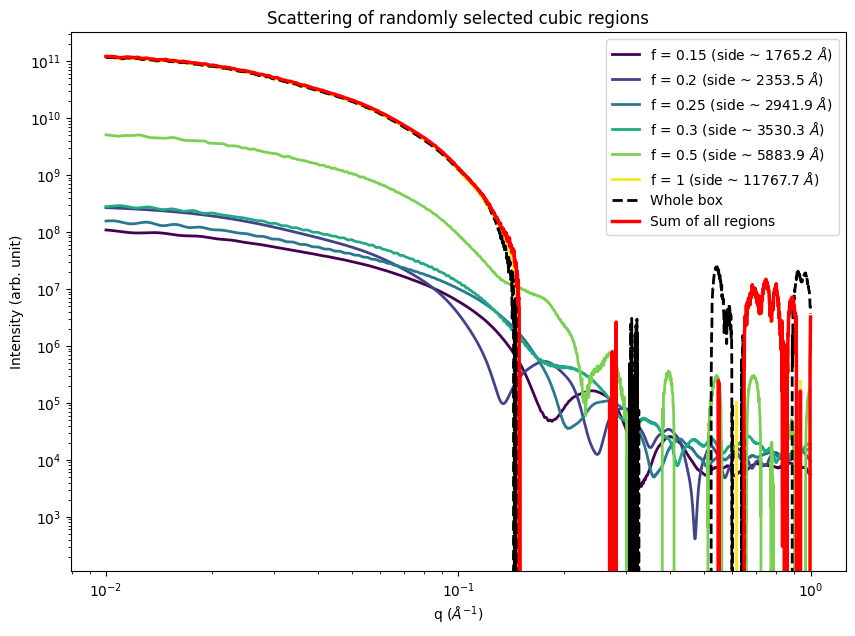

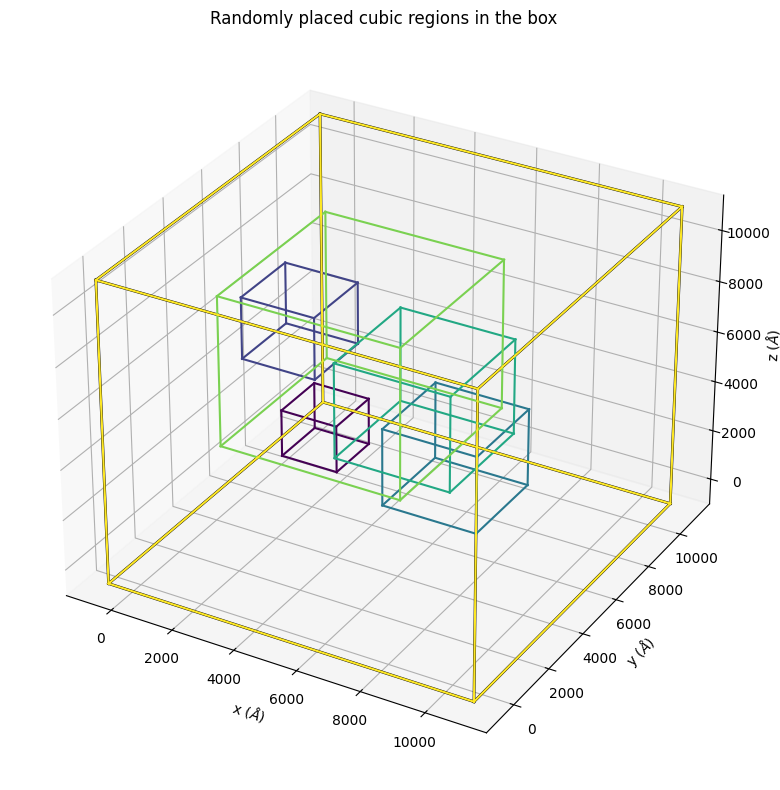

In [2]:
n_samples = 10000000          # same value used elsewhere in the code
simulator = pairwise_method.scattering_simulator(n_samples)
I_whole, I_subs, I_summed, box_info = simulator.simulate_scattering_curve_box(
    all_coordinates, histogram_bins, q
)

In [3]:
import pandas as pd
rods = pd.read_csv('sasview_intensity.txt', delimiter=' ').values

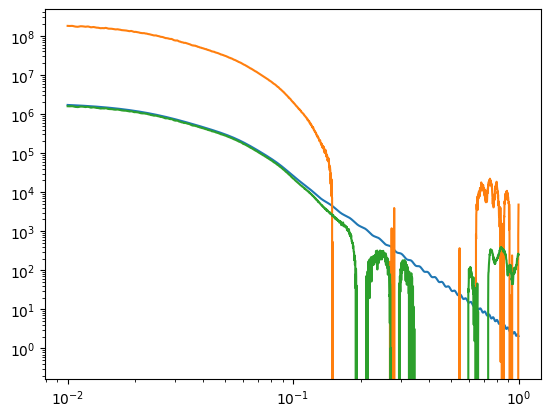

In [4]:
plt.loglog(rods[:,0], rods[:,1])
plt.loglog(q, I_summed*1.5e-3)
plt.loglog(q, Iq)

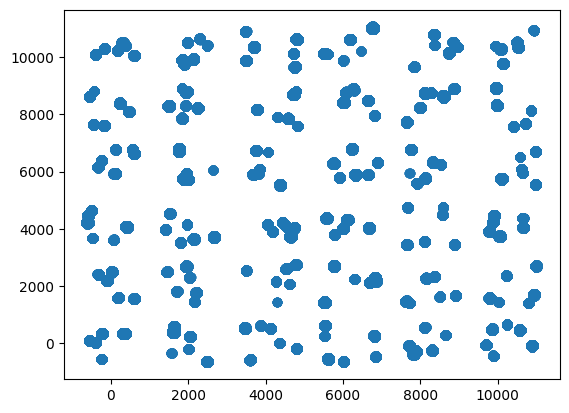

In [5]:
plt.scatter(all_coordinates[:,0], all_coordinates[:,1])